## Off Policy Monte Carlo Control

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
from tqdm.notebook import trange
import matplotlib.colors as mcolors

In [2]:
class GridworldEnv:
    def __init__(self, grid_size, holes=[]):
        self.grid_size = grid_size
        self.states = [(i, j) for i in range(grid_size) for j in range(grid_size)]
        self.terminal_states = [(0, 0), (grid_size-1, grid_size-1)]
        self.actions = ['up', 'down', 'left', 'right']
        self.holes = holes
        self.rewards = {s: -1 for s in self.states}
        self.rewards[(0, 0)] = 0
        self.rewards[(grid_size-1, grid_size-1)] = 1
        self.gamma = 0.9
        for hole in holes:
            self.rewards[hole] = -np.inf  # Holes have a very negative reward

    def is_terminal(self, state):
        return state in self.terminal_states

    def is_hole(self, state):
        return state in self.holes

    def get_next_state(self, state, action):
        if self.is_terminal(state) or self.is_hole(state):
            return state
        i, j = state
        if action == 'up':
            next_state = (max(i-1, 0), j)
        elif action == 'down':
            next_state = (min(i+1, self.grid_size-1), j)
        elif action == 'left':
            next_state = (i, max(j-1, 0))
        elif action == 'right':
            next_state = (i, min(j+1, self.grid_size-1))
        if self.is_hole(next_state):
            return state  # Stay in the same state if the next state is a hole
        return next_state

    def get_tprob_and_rewards(self, state, action):
        next_state = self.get_next_state(state, action)
        return [(1.0, next_state, self.rewards[next_state])]

    def display_grid(self, filename='gridworld_states.png'):
        fig, ax = plt.subplots()
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                state = (i, j)
                if state in self.terminal_states:
                    color = 'gray'
                elif state in self.holes:
                    color = 'black'
                else:
                    color = 'white'
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, edgecolor='black', facecolor=color))
                ax.text(j + 0.5, i + 0.5, f'({i},{j})', ha='center', va='center')
        ax.set_xlim(0, self.grid_size)
        ax.set_ylim(0, self.grid_size)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.title("Gridworld States")
        plt.gca().invert_yaxis()
        plt.savefig(filename, dpi=300)
        plt.show()

In [3]:
# Initialize the environment
holes = [(1, 1), (2, 2)]
env = GridworldEnv(grid_size=6, holes=holes)

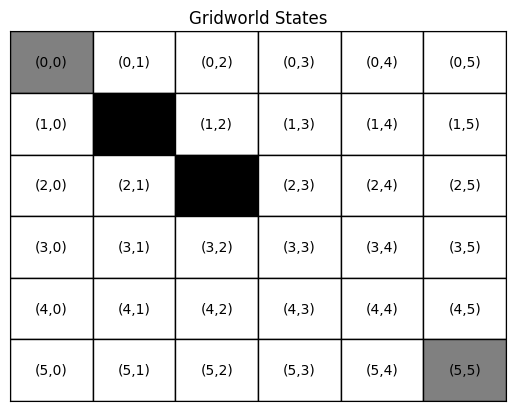

In [4]:
env.display_grid()

### Monte Carlo Policy Evaluation

In [5]:
def epsilon_greedy_policy(Q, state, epsilon, actions):
    if random.random() < epsilon:
        return random.choice(actions)
    else:
        return max(actions, key=lambda a: Q[state][a])

def sarsa(env, num_episodes, alpha=0.1, gamma=0.99, epsilon=0.1, max_count=100):
    Q = defaultdict(lambda: defaultdict(float))
    
    for _ in trange(num_episodes):
        state = random.choice(env.states)
        while env.is_terminal(state):
            state = random.choice(env.states)
        
        action = epsilon_greedy_policy(Q, state, epsilon, env.actions)
        count = 0
        while not env.is_terminal(state):
            if count < max_count:
                next_state = env.get_next_state(state, action)
                reward = env.rewards[next_state]
                next_action = epsilon_greedy_policy(Q, next_state, epsilon, env.actions)
                td_target = reward + gamma * Q[next_state][next_action]
                td_error = td_target - Q[state][action]
                Q[state][action] += alpha * td_error
                state = next_state
                action = next_action
                count += 1
            else:
                break
    
    # Extract the optimal policy from Q
    optimal_policy = {state: max(env.actions, key=lambda a: Q[state][a]) for state in env.states}
    return Q, optimal_policy


In [6]:
# Run the algorithm
num_episodes = 1000000
Q, optimal_policy = sarsa(env, num_episodes)

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [7]:
def calculate_value_function(Q):
    V = defaultdict(float)
    for state in Q:
        V[state] = max(Q[state].values())
    return V

In [8]:
V = calculate_value_function(Q)

In [9]:
def plot_value_function(value_function, grid_size, title, filename='', cmap='viridis'):
    values = np.zeros((grid_size, grid_size))
    for (i, j), value in value_function.items():
        values[i, j] = value
    fig, ax = plt.subplots()
    cax = ax.matshow(values, cmap=cmap)
    text_color = 'white'
    if cmap == 'Greys':
        text_color = '0.5'
    for (i, j), value in value_function.items():
        ax.text(j, i, f"{value:.2f}", va='center', ha='center', color=text_color)
    fig.colorbar(cax)
    plt.title(title)
    if filename != '':
        plt.savefig(filename, dpi=300)
    plt.show()

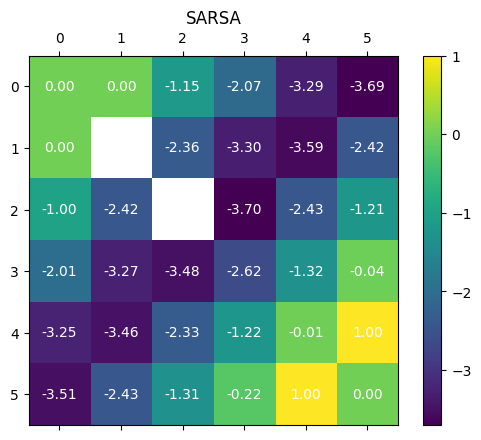

In [10]:
plot_value_function(V, env.grid_size, 'SARSA', 'gridworld_op_sarsa.png')

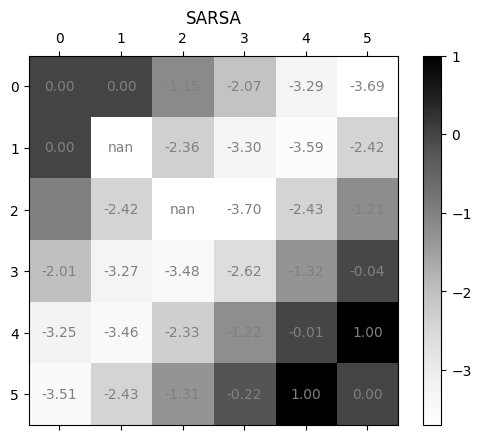

In [11]:
plot_value_function(V, env.grid_size, 'SARSA', 'gridworld_op_sarsa_bw.png', 'Greys')

In [12]:
# Plotting the Optimal Policy
def plot_policy(policy, grid_size, filename=''):
    fig, ax = plt.subplots()
    for state, action in policy.items():
        if state in [(0, 0), (grid_size-1, grid_size-1)]:
            continue
        i, j = state
        if action == 'up':
            ax.arrow(j, grid_size-i-1, 0, 0.3, head_width=0.1, head_length=0.1, fc='k', ec='k')
        elif action == 'down':
            ax.arrow(j, grid_size-i-1, 0, -0.3, head_width=0.1, head_length=0.1, fc='k', ec='k')
        elif action == 'left':
            ax.arrow(j, grid_size-i-1, -0.3, 0, head_width=0.1, head_length=0.1, fc='k', ec='k')
        elif action == 'right':
            ax.arrow(j, grid_size-i-1, 0.3, 0, head_width=0.1, head_length=0.1, fc='k', ec='k')
    ax.set_xlim(-0.5, grid_size-0.5)
    ax.set_ylim(-0.5, grid_size-0.5)
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.set_xticklabels(range(grid_size))
    ax.set_yticklabels(range(grid_size-1, -1, -1))
    ax.grid(True)
    plt.title("Optimal Policy")
    if filename != '':
        plt.savefig(filename, dpi=300)
    plt.show()

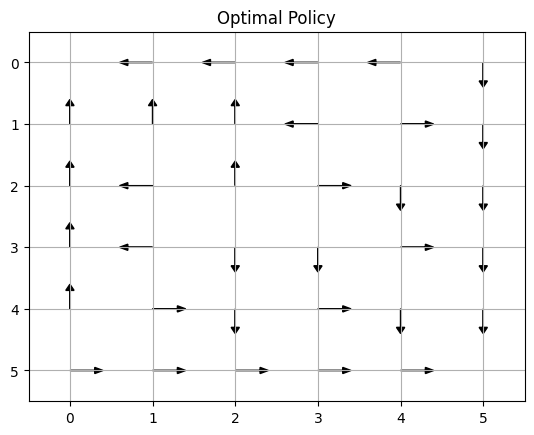

In [13]:
plot_policy(optimal_policy, env.grid_size, 'gridworld_sarsa_op.png')

In [14]:
def plot_q_function(q, grid_size, title, action, filename='', cmap='viridis'):
    values = np.zeros((grid_size, grid_size))
    for (i, j), value in q.items():
        values[i, j] = value[action]
    fig, ax = plt.subplots()
    cax = ax.matshow(values, cmap=cmap)
    text_color = 'white'
    if cmap == 'Greys':
        text_color = '0.5'
    for (i, j), value in q.items():
        ax.text(j, i, f"{value[action]:.2f}", va='center', ha='center', color=text_color)
    fig.colorbar(cax)
    plt.title(title)
    if filename != '':
        plt.savefig(filename, dpi=300)
    plt.show()

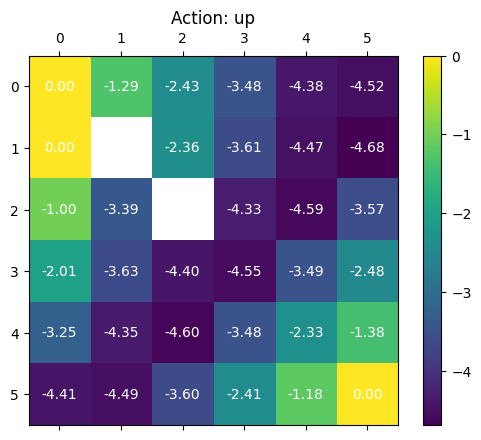

In [15]:
# Plot the Q-function
plot_q_function(Q, env.grid_size, 'Action: up', 'up')

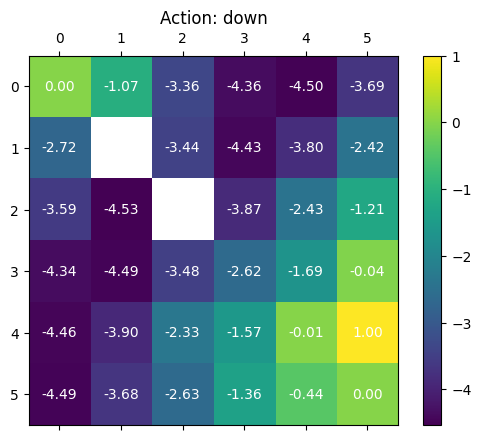

In [16]:
plot_q_function(Q, env.grid_size, 'Action: down', 'down')

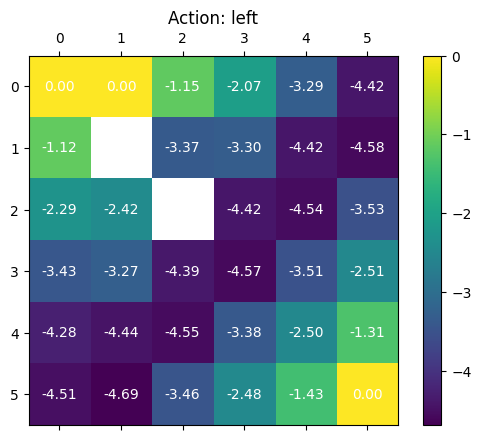

In [17]:
plot_q_function(Q, env.grid_size, 'Action: left', 'left')

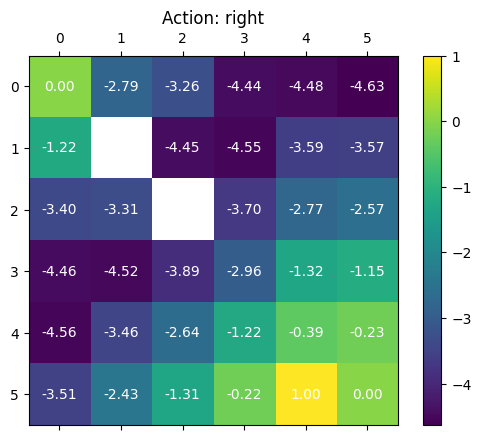

In [18]:
plot_q_function(Q, env.grid_size, 'Action: right', 'right')

In [19]:
optimal_policy

{(0, 0): 'up',
 (0, 1): 'left',
 (0, 2): 'left',
 (0, 3): 'left',
 (0, 4): 'left',
 (0, 5): 'down',
 (1, 0): 'up',
 (1, 1): 'up',
 (1, 2): 'up',
 (1, 3): 'left',
 (1, 4): 'right',
 (1, 5): 'down',
 (2, 0): 'up',
 (2, 1): 'left',
 (2, 2): 'up',
 (2, 3): 'right',
 (2, 4): 'down',
 (2, 5): 'down',
 (3, 0): 'up',
 (3, 1): 'left',
 (3, 2): 'down',
 (3, 3): 'down',
 (3, 4): 'right',
 (3, 5): 'down',
 (4, 0): 'up',
 (4, 1): 'right',
 (4, 2): 'down',
 (4, 3): 'right',
 (4, 4): 'down',
 (4, 5): 'down',
 (5, 0): 'right',
 (5, 1): 'right',
 (5, 2): 'right',
 (5, 3): 'right',
 (5, 4): 'right',
 (5, 5): 'up'}